In [1]:
using IonSim
using QuantumOptics
using PyPlot

function plot_wigner(final_state)
    rho_motional = ptrace(final_state, 1)

b_fock = FockBasis(20)
rho_fock = DenseOperator(b_fock, rho_motional.data)

x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

W = wigner(rho_fock, x_vec, p_vec)

fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)
end


function SDF_apply_with_alpha(angle = 0, time = 50.0, cat_state = false, initial_state = nothing)

    red_angle = (π - 2*angle ) /2
    blue_angle = red_angle + 2 *angle

    if (cat_state)
        println("Preparing cat state superposition...")
        red_angle = -angle
        blue_angle = angle
    end
    trap_freq = 19e5 # 1 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 20
    mode_z.shape = [21]

   k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ

    laser_intensity = 1e6 # Adjust this to push the ion faster/slower
    B_field = 1e-13
    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap)

    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

    mode = zmodes(trap)[1]
    println(mode)

    ψ_ion = normalize(ion["g"] -  ion["e"])

    
    ψ_mode = fockstate(mode, 0)
    ψ_initial = ψ_ion ⊗ ψ_mode

    if (initial_state != nothing)
        println("Using provided initial state...")
        ψ_initial = initial_state
    end

    h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
    tspan = 0:0.5:time 
    println("Simulating bichromatic displacement...")
    tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

    final_state = sol[end]

    # ---------------------------------------------------------
# 1. Fundamental Physics Constants
# ---------------------------------------------------------
 hbar = 1.0545718e-34       # Reduced Planck constant (J*s)
 amu = 1.66053906e-27       # Atomic mass unit (kg)
 m_Ca40 = 39.96259 * amu    # Mass of Calcium-40 ion (kg)
 c = 2.99792458e8           # Speed of light (m/s)

# ---------------------------------------------------------
# 2. Your Simulated Experiment Parameters
# ---------------------------------------------------------     
wavelength = transition_λ             # Quadrupole transition wavelength (m)
tspan_end = time * 1e-6              # Total laser interaction time (s)
# ---------------------------------------------------------
# 3. Step-by-Step Calculation
# ---------------------------------------------------------

println("--- VERIFYING DISPLACEMENT PARAMETERS ---")

# Step A: Zero-Point Fluctuation (z_zpf)
# z_zpf = sqrt( ħ / (2 * m * ω_trap) )
omega_trap = 2 * π * trap_freq
z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
println("Zero-Point Fluctuation (z_zpf) : ", round(z_zpf * 1e9, digits=4), " nm")

# Step B: Wavevector Z-Projection (k_z)
# Your vector: k_vec = (x̂ + ẑ) / √2 
# Therefore, projection onto Z is 1/√2
k_total = 2 * π / wavelength
k_z = k_total / sqrt(2)
println("Z-Projected Wavevector (k_z)   : ", round(k_z, digits=2), " m⁻¹")

# Step C: Lamb-Dicke Parameter (η)
# η = k_z * z_zpf
eta = k_z * z_zpf
println("Lamb-Dicke Parameter (η)       : ", round(eta, digits=4))

# Step D: Effective Rabi Frequency (Ω_eff)
# The geometric coupling factor for a Δm=0 quadrupole transition using your 
# specific k_vec and ϵ_vec vectors results in a scaling reduction of 1/4.
# geometric_factor = 1.0 / 4.0
geometric_factor = 1.0 / ( sqrt(3)) 

# STRETCHED STATE: The CG coefficient is exactly 1.0! 
cg_factor = 1.0 # The Clebsch-Gordan factor for Δm=0 in Ca40

# The true effective Rabi frequency acting on the ion's orbitals
Omega_eff = laser_intensity * geometric_factor * cg_factor
println("Effective Rabi Freq (Ω_eff)    : ", Omega_eff, " rad/s")

# Step E: Displacement Magnitude (|α|)
# |α| = 1/2 * η * Ω_eff * t 
alpha_mag = 0.5 * eta * Omega_eff * tspan_end 

println("-----------------------------------------")
println("FINAL DISPLACEMENT MAGNITUDE (|α| = 0.5 * η * Ω_eff * t) : ", round(alpha_mag, digits=3))
println("-----------------------------------------")
return final_state
end

trap_freq = 19e5 # 1.9 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 20
    mode_z.shape = [21]

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ

    laser_intensity = 1e6 # Fixed intensity
    B_field = 1e-13
    
    # Pre-build a trap just to grab the transition wavelength
    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap)
    mode = zmodes(trap)[1]
    println(mode)
    ψ_ion = normalize(ion["g"] - ion["e"])
    ψ_mode = fockstate(mode, 0)
    ψ_initial = ψ_ion ⊗ ψ_mode

    # 1. Grab the exact mode object used in the simulation (no generic FockBasis!)
sim_mode = zmodes(trap)[1]
a = 0.716 * im 

# 2. Build the displacement operator using the IonSim mode
# IonSim has a built-in displace() method specifically for VibrationalModes
D_motion = IonSim.displace(sim_mode, a)

# 3. Create a "Do Nothing" operator for the ion's spin
I_spin = identityoperator(ion["g"].basis)

 ψ_ion = normalize(ion["g"] -  ion["e"])

# 4. Combine them into a full system operator (Spin ⊗ Motion)
D_system = identityoperator(ψ_ion.basis) ⊗ D_motion

# 5. Apply the operator to the state (The bases now match perfectly!)
displaced_final_state = D_system * ψ_initial

println(displaced_final_state)

function SDF_apply_with_alpha(angle = 0, target_alpha = 0.716, cat_state = false, initial_state = nothing, fock_state_n = 0)

    red_angle = (π - 2*angle ) /2
    blue_angle = red_angle + 2 *angle

    if (cat_state)
        # println("Preparing cat state superposi/tion...")
        red_angle = -angle
        blue_angle = angle
    end
    
    trap_freq = 19e5 # 1.9 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 20
    mode_z.shape = [21]

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ

    laser_intensity = 1e4 # Fixed intensity
    B_field = 1e-13
    
    # Pre-build a trap just to grab the transition wavelength
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)

    # ---------------------------------------------------------
    # NEW: DYNAMIC TIME CALCULATION VIA WIGNER-ECKART ENGINE
    # ---------------------------------------------------------
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    c = 2.99792458e8           

    # 1. Calculate Lamb-Dicke Parameter (η) dynamically
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    # 2. Hijack IonSim's internal matrix element calculator
    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    # Feed the dummy laser into the exact internal physics engine
    # (Note: Unexported internal functions need the module prefix 'IonSim.')
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    # 3. Solve the displacemen formula backward to find exactly how long to leave the lasers on
    target_time_s = (2 * target_alpha) / (eta * Omega_eff)
    target_time_us = target_time_s * 1e6
    # ---------------------------------------------------------

    # Now build the actual lasers and final chamber
    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

    mode = zmodes(trap)[1]
    # println(mode)

    ψ_ion = normalize(ion["g"] - ion["e"])
    ψ_mode = fockstate(mode, fock_state_n)
    ψ_initial = ψ_ion ⊗ ψ_mode

    if (initial_state != nothing)
        ψ_initial = initial_state
    end

    h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
    
    # Ensure our solver array steps exactly up to our calculated target time
    tspan_array = collect(0:0.5:target_time_us)
    if tspan_array[end] < target_time_us
        push!(tspan_array, target_time_us)
    end

    tout, sol = timeevolution.schroedinger_dynamic(tspan_array, ψ_initial, h)

    final_state = sol[end]
    
    return final_state
end

function protocol(initialstate = nothing, beta = 1, alpha = 0.5)

    beta_state = SDF_apply_with_alpha(0, beta, false, initialstate, 0)
    final_state = SDF_apply_with_alpha(pi/2, alpha, true, beta_state, 0)

    return final_state
end

using LinearAlgebra

function calculate_qcrb(state, state_perturbed, d_alpha::Float64; tol=1e-10)
    
    # 1. Promote pure states (Ket) to density matrices
    rho1 = isa(state, Ket) ? dm(state) : state
    rho2 = isa(state_perturbed, Ket) ? dm(state_perturbed) : state_perturbed
    
    # 2. Extract dense data
    rho_dense_data = dense(rho1).data
    rho_pert_dense_data = dense(rho2).data

    # 3. Finite difference derivative
    drho_data = (rho_pert_dense_data - rho_dense_data) / d_alpha
    
    # 4. Use Hermitian() to guarantee real eigenvalues and speed up diagonalization
    λ, V = LinearAlgebra.eigen(Hermitian(rho_dense_data))
    
    qfi = 0.0
    n = length(λ)
    
    for i in 1:n
        for j in 1:n
            if real(λ[i] + λ[j]) > tol
                # 5. Use @views to prevent memory allocation during column slicing
                @views v_i = V[:, i]
                @views v_j = V[:, j]
                
                drho_ij = dot(v_i, drho_data * v_j)
                qfi += 2 * (abs(drho_ij)^2) / real(λ[i] + λ[j])
            end
        end
    end
    
    qcrb = qfi > 0 ? 1.0 / qfi : Inf
    return qfi, qcrb
end


VibrationalMode(ν=1.9e6, axis=ẑ, N=20)
Ket(dim=42)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=20)]
     0.54722151763696 + 0.0im
    -0.54722151763696 + 0.0im
                  0.0 + 0.3918106066280634im
                  0.0 - 0.3918106066280634im
  -0.1983691868114632 + 0.0im
   0.1983691868114632 + 0.0im
                  0.0 - 0.08200240843764023im
                  0.0 + 0.08200240843764023im
   0.0293568622206752 + 0.0im
  -0.0293568622206752 + 0.0im
                  0.0 + 0.0094002121409144im
                  0.0 - 0.0094002121409144im
 -0.00274773630415258 + 0.0im
  0.00274773630415258 + 0.0im
                  0.0 - 0.00074359944018383im
                  0.0 + 0.00074359944018383im
   0.0001882379059773 + 0.0im
  -0.0001882379059773 + 0.0im
                  0.0 + 4.492611355992e-5im
                  0.0 - 4.492611355992e-5im
   -1.017212932124e-5 + 0.0im
    1.017212932124e-5 + 0.0im
                  0.0 - 2.19598087043e-6im
                  0.0 + 2.195980870

calculate_qcrb (generic function with 1 method)

In [30]:
angle = 0
 target_alpha = 0.716
 cat_state = false
 initial_state = nothing
 fock_state_n = 0
red_angle = (π - 2*angle ) /2
    blue_angle = red_angle + 2 *angle

    if (cat_state)
        # println("Preparing cat state superposi/tion...")
        red_angle = -angle
        blue_angle = angle
    end
    
    trap_freq = 19e5 # 1.9 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 20
    mode_z.shape = [21]

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ

    laser_intensity = 1e4 # Fixed intensity
    B_field = 1e-13
    
    # Pre-build a trap just to grab the transition wavelength
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)

    # ---------------------------------------------------------
    # NEW: DYNAMIC TIME CALCULATION VIA WIGNER-ECKART ENGINE
    # ---------------------------------------------------------
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    c = 2.99792458e8           

    # 1. Calculate Lamb-Dicke Parameter (η) dynamically
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    # 2. Hijack IonSim's internal matrix element calculator
    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    # Feed the dummy laser into the exact internal physics engine
    # (Note: Unexported internal functions need the module prefix 'IonSim.')
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    # 3. Solve the displacemen formula backward to find exactly how long to leave the lasers on
    target_time_s = (2 * target_alpha) / (eta * Omega_eff)
    target_time_us = target_time_s * 1e6
    # ---------------------------------------------------------

    # Now build the actual lasers and final chamber
    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

    mode = zmodes(trap)[1]
    # println(mode)

    ψ_ion = normalize(ion["g"] - ion["e"])
    ψ_mode = fockstate(mode, fock_state_n)
    ψ_initial = ψ_ion ⊗ ψ_mode

    if (initial_state != nothing)
        ψ_initial = initial_state
    end

    h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
    
    # Ensure our solver array steps exactly up to our calculated target time
    tspan_array = collect(0:0.5:target_time_us)
    if tspan_array[end] < target_time_us
        push!(tspan_array, target_time_us)
    end

    tout, sol = timeevolution.schroedinger_dynamic(tspan_array, ψ_initial, h)

    final_state = sol[end]

Ket(dim=42)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=20)]
   0.5450820358285609 + 1.635918533116e-5im
  -0.5500726555082338 - 1.599621709875e-5im
   -6.180007816265e-5 + 0.3899229688953799im
    6.128170547948e-5 - 0.39348410460133865im
 -0.19698925582668392 - 5.651149477571e-5im
   0.1987846999184553 + 5.611775751378e-5im
    3.369306417941e-5 - 0.08115698796141489im
   -3.347597511766e-5 + 0.08189413762624549im
  0.02891994639159961 + 1.571345069334e-5im
 -0.02918234541016348 - 1.561670813688e-5im
                      ⋮
       -4.8711632e-10 - 9.9585e-13im
          -1.8072e-13 + 8.212948e-11im
           1.7974e-13 - 8.284704e-11im
        -1.355839e-11 - 3.155e-14im
         1.367755e-11 + 3.138e-14im
             5.34e-15 - 2.174e-12im
            -5.31e-15 + 2.19288e-12im
           3.5033e-13 + 8.7e-16im
          -3.5348e-13 - 8.7e-16im

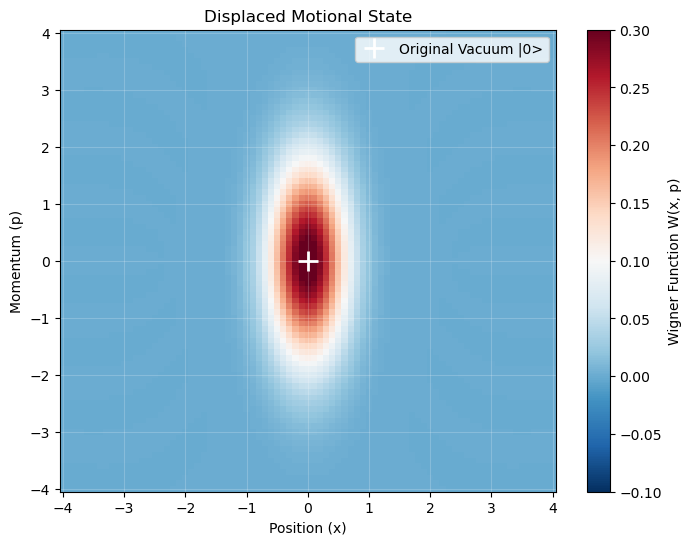

In [2]:
cutoff = 20
b = FockBasis(cutoff)
vac = fockstate(b, 0)

# 2. Define squeeze parameter z (z = r * exp(i * theta))
z = 0.5 * exp(1im * pi) 

# 3. Create the squeezed state by applying the squeeze operator to the vacuum
squeeze_op = squeeze(b, z)
squeezed_vac = squeeze_op * vac

state = ψ_ion ⊗ squeezed_vac

plot_wigner(state)

In [3]:
sim_mode = zmodes(trap)[1]
    
    # 1. Create a temporary standard FockBasis of the EXACT same dimension
    temp_fock_basis = FockBasis(sim_mode.N)
    
    # 2. Use QuantumOptics to calculate the complex squeeze matrix
    z = 0.5 * exp(1im * pi) 
    S_fock = squeeze(temp_fock_basis, z) 
    
    # 3. THE FIX: Wrap the raw matrix data back into the IonSim mode!
    squeeze_op = DenseOperator(sim_mode, sim_mode, S_fock.data)
    
    # 4. Build the vacuum state directly on the IonSim mode
    vac = fockstate(sim_mode, 0)
    
    # 5. Apply the wrapped squeeze operator
    ψ_mode = squeeze_op * vac
    
    # 6. Tensor the spin and the mode together
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    # NOW APPLY SIGNAL: The dimensions and types match perfectly!
    ψ_initial_perturbed = D_system * ψ_initial

Ket(dim=42)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=20)]
   0.4577590108951626 + 1.0e-17im
  -0.4577590108951626 - 1.0e-17im
              1.0e-17 + 0.4792168694118958im
             -1.0e-17 - 0.4792168694118958im
 -0.20516158193926037 + 1.0e-17im
  0.20516158193926037 - 1.0e-17im
              2.0e-17 + 0.05681416305039548im
             -2.0e-17 - 0.05681416305039548im
 -0.11184541535708561 + 2.0e-17im
  0.11184541535708561 - 2.0e-17im
                      ⋮
 -0.00081590509022365 + 0.0im
                 -0.0 + 2.065117134781e-5im
                  0.0 - 2.065117134781e-5im
  0.00032509848675729 - 0.0im
 -0.00032509848675729 + 0.0im
                  0.0 + 5.824173213695e-5im
                 -0.0 - 5.824173213695e-5im
    8.602640788944e-5 - 0.0im
   -8.602640788944e-5 + 0.0im

In [14]:
# ---------------------------------------------------------
# Define Lindblad Jump Operators for Anomalous Heating
# ---------------------------------------------------------
n_th = 100.0             # High thermal phonon occupancy for surface trap bath
gamma_0 = 1e-4           # Intrinsic coupling rate
gamma_plus = gamma_0 * n_th       # Anomalous heating rate (phonon gain)
gamma_minus = gamma_0 * (n_th + 1) # Cooling rate (phonon loss)

# Ladder operators for the motional mode
# FIX: explicitly build the FockBasis using the cutoff dimension N
b_motional = FockBasis(sim_mode.N) 
a_op = QuantumOptics.destroy(b_motional)
at_op = QuantumOptics.create(b_motional)

# Extend operators to the full bipartite system (Spin ⊗ Motion)
a_sys = I_spin ⊗ a_op
at_sys = I_spin ⊗ at_op

# Define jump operators (L_k)
J_heat = sqrt(gamma_plus) * at_sys
J_cool = sqrt(gamma_minus) * a_sys
J_ops = [J_cool, J_heat]

2-element Vector{Operator{CompositeBasis{Vector{Int64}, Tuple{IonInstance{:Ca40}, FockBasis{Int64}}}, CompositeBasis{Vector{Int64}, Tuple{IonInstance{:Ca40}, FockBasis{Int64}}}, SparseArrays.SparseMatrixCSC{ComplexF64, Int64}}}:
 Operator(dim=42x42)
  basis: [⁴⁰Ca ⊗ Fock(cutoff=20)]
⎡⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎤
⎢⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⎥
⎣⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎦
 Operator(dim=42x42)
  basis: [⁴⁰Ca ⊗ Fock(cutoff=20)]
⎡⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎤
⎢⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⠀⠀⎥
⎢⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⢄⠀⠀⎥
⎣⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠑⠀⎦

Simulating Ordinary Vacuum |0⟩...
Target α: 0.01 (Lasers on for 6.98 μs), State: Vacuum, QCRB: 625.261
Target α: 0.06 (Lasers on for 41.87 μs), State: Vacuum, QCRB: 17.682
Target α: 0.11 (Lasers on for 76.76 μs), State: Vacuum, QCRB: 5.555
Target α: 0.16 (Lasers on for 111.65 μs), State: Vacuum, QCRB: 2.914
Target α: 0.21 (Lasers on for 146.54 μs), State: Vacuum, QCRB: 2.002
Target α: 0.26 (Lasers on for 181.43 μs), State: Vacuum, QCRB: 1.668
Target α: 0.31 (Lasers on for 216.32 μs), State: Vacuum, QCRB: 1.642
Target α: 0.36 (Lasers on for 251.21 μs), State: Vacuum, QCRB: 1.892
Target α: 0.41 (Lasers on for 286.1 μs), State: Vacuum, QCRB: 2.55
Target α: 0.46 (Lasers on for 320.99 μs), State: Vacuum, QCRB: 4.071
Target α: 0.51 (Lasers on for 355.88 μs), State: Vacuum, QCRB: 7.767
Target α: 0.56 (Lasers on for 390.77 μs), State: Vacuum, QCRB: 18.217
Target α: 0.61 (Lasers on for 425.67 μs), State: Vacuum, QCRB: 53.664
Target α: 0.66 (Lasers on for 460.56 μs), State: Vacuum, QCRB: 200.902

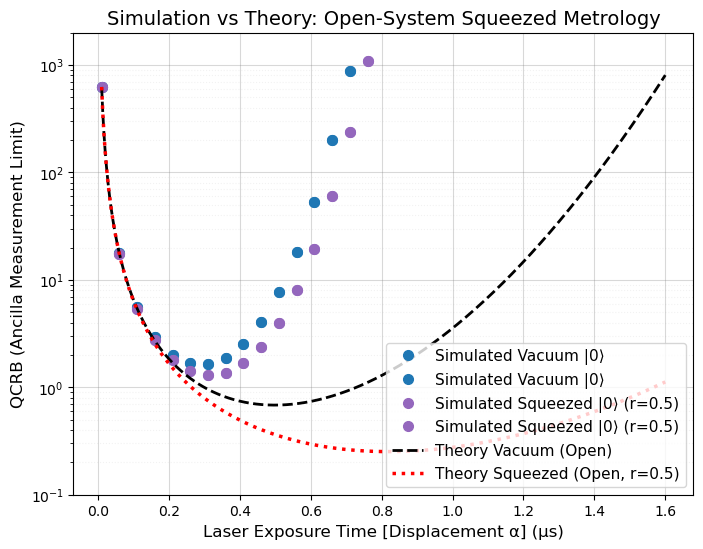

In [34]:
# ---------------------------------------------------------
# QCRB Simulation Loop: Squeezed vs Vacuum (Open System)
# ---------------------------------------------------------
using QuantumOptics
using IonSim

t_max = 1.6
time_steps = 0.01:0.05:t_max 
states = 0:1 
ψ_ion = normalize(ion["g"] - ion["e"])
d_alpha = 0.01

fig = figure(figsize=(8, 6))
qcrb_matrix = zeros(Float64, length(states), length(time_steps))

# Pre-build the signal operator once to save loop time
sim_mode = zmodes(trap)[1]
D_signal = IonSim.displace(sim_mode, im * d_alpha)
I_spin = identityoperator(ion["g"].basis)
D_system = I_spin ⊗ D_signal

# Squeezing parameter
r_squeeze = 0.5

# ---------------------------------------------------------
# Define Lindblad Jump Operators for Anomalous Heating
# ---------------------------------------------------------
n_th = 100.0             # High thermal phonon occupancy for surface trap bath
gamma_0 = 1e-4           # Intrinsic coupling rate
gamma_plus = gamma_0 * n_th       # Anomalous heating rate (phonon gain)
gamma_minus = gamma_0 * (n_th + 1) # Cooling rate (phonon loss)

# 1. Create pure math ladder operators in Fock space
temp_fock_basis = FockBasis(sim_mode.N) 
a_fock = QuantumOptics.destroy(temp_fock_basis)
at_fock = QuantumOptics.create(temp_fock_basis)

# 2. Trick QuantumOptics by wrapping them in the exact IonSim VibrationalMode basis
a_op = DenseOperator(sim_mode, sim_mode, a_fock.data)
at_op = DenseOperator(sim_mode, sim_mode, at_fock.data)

# 3. Extend operators to the full bipartite system (Spin ⊗ Motion)
a_sys = I_spin ⊗ a_op
at_sys = I_spin ⊗ at_op

# 4. Define jump operators (L_k) and their conjugates
J_heat = sqrt(gamma_plus) * at_sys
J_cool = sqrt(gamma_minus) * a_sys
J_ops = [J_cool, J_heat]
J_ops_dag = dagger.(J_ops)

# ---------------------------------------------------------
# Simulation Loop
# ---------------------------------------------------------
for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    if n == 0
        println("Simulating Ordinary Vacuum |0⟩...")
        ψ_mode = fockstate(sim_mode, 0)
        label_sim = "Simulated Vacuum |0⟩"
        color_sim = "tab:blue"
    else
        println("Simulating Squeezed Vacuum (r = $r_squeeze)...")
        temp_fock_basis = FockBasis(sim_mode.N)
        z = r_squeeze * exp(1im * pi) 
        S_fock = squeeze(temp_fock_basis, z) 
        
        squeeze_op = DenseOperator(sim_mode, sim_mode, S_fock.data)
        vac = fockstate(sim_mode, 0)
        ψ_mode = squeeze_op * vac
        
        label_sim = "Simulated Squeezed |0⟩ (r=$r_squeeze)"
        color_sim = "tab:purple"
    end
    
    # Initialize full states as Density Matrices for open system dynamics
    ψ_initial = ψ_ion ⊗ ψ_mode
    rho_initial = dm(ψ_initial)
    
    # APPLY SIGNAL FIRST: Create the perturbed initial density matrix
    ψ_initial_perturbed = D_system * ψ_initial
    rho_initial_perturbed = dm(ψ_initial_perturbed)

    angle = pi/2
red_angle = -angle
blue_angle = angle

# Create the specific laser pulses
L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Build the active Chamber (The trap with the lasers turned ON)
trap_active = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

# Generate the time-dependent Hamiltonian for the open-system solver
H_SDF_active = hamiltonian(trap_active, timescale=1e-6, rwa_cutoff=Inf)
    

    # =====================================================================
# 1. PRE-CALCULATE DYNAMIC TIME PARAMETERS
# =====================================================================
# Ensure these variables match your specific hardware definitions
hbar = 1.0545718e-34
amu = 1.66053906e-27
m_Ca40 = 39.96259 * amu

omega_trap = 2 * pi * trap_freq
z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
k_total = 2 * pi / transition_λ
k_z = k_total / sqrt(2)
eta = k_z * z_zpf

# Hijack IonSim's internal matrix element calculator
dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
Omega_eff = Omega_eff_Hz * 2 * pi

# =====================================================================
# 2. THE LINDBLAD SOLVER LOOP (DRIVEN BY TARGET ALPHA)
# =====================================================================
# We want the x-axis to be alpha, so we loop over alpha, not arbitrary time!
alpha_max = 1.6
alpha_steps = 0.01:0.05:alpha_max

# (Make sure to update your matrix initialization to use alpha_steps!)
# qcrb_matrix = zeros(Float64, length(states), length(alpha_steps))

for (j, target_alpha) in enumerate(alpha_steps)
    
    # Solve the Wigner-Eckart formula backward to find the EXACT time needed in microseconds
    target_time_s = (2 * target_alpha) / (eta * Omega_eff)
    t_us = target_time_s * 1e6
    
    # Define the dynamic callback function for the Lindblad solver
    function f_dyn(time_t, rho_state)
        return (H_SDF_active(time_t, rho_state), J_ops, J_ops_dag)
    end
    
    # 1. Run the solver up to the calculated microsecond
    tout, rho_base_t = timeevolution.master_dynamic([0.0, t_us], rho_initial, f_dyn)
    ancilla = ptrace(rho_base_t[end], 2) 
    
    # 2. Extract the Visibility (V) directly from the Spin Coherence
    coherence = abs(ancilla.data[1, 2])
    V_sim = 2.0 * coherence
    
    # 3. Calculate QCRB Analytically from the Simulated V and target_alpha
    qfi_sim = 16.0 * (target_alpha^2) * (V_sim^2)
    qcrb = 1.0 / (qfi_sim + 1e-15) 
    
    push!(qcrb_values, qcrb)
    qcrb_matrix[i, j] = qcrb
    
    println("Target α: ", round(target_alpha, digits=3), " (Lasers on for ", round(t_us, digits=2), " μs), State: ", n==0 ? "Vacuum" : "Squeezed", ", QCRB: ", round(qcrb, digits=3))
end

# ---------------------------------------------------------
# CRITICAL: Plot against alpha_steps, not time_steps!
# ---------------------------------------------------------
PyPlot.plot(alpha_steps, qcrb_values, "o", color=color_sim, markersize=7, label=label_sim)
    
    # Plot simulation as scatter dots
    PyPlot.plot(time_steps, qcrb_values, "o", color=color_sim, markersize=7, label=label_sim)
end

# ---------------------------------------------------------
# Analytical Theory Overlay (Open System)
# ---------------------------------------------------------
alphas_theory = range(0.01, stop=t_max, length=1000)

# The effective decoherence rate (Γ)
Gamma_eff = (gamma_plus + gamma_minus) / 2

# Assuming displacement α is proportional to time t for plotting (α ≈ t).
# If your mapping is different (e.g. α = ηΩt), apply that scaling here.
t_theory = alphas_theory 

# 1. Open System Theory for Ordinary Vacuum (r = 0, n = 0)
decay_penalty_0 = @. exp(4 * Gamma_eff * t_theory * alphas_theory^2)
qcrb_theory_0_open = @. (exp(4 * alphas_theory^2) * decay_penalty_0) / (16 * alphas_theory^2 + 1e-15)

# 2. Open System Theory for Squeezed Vacuum (r = r_squeeze, n = 0)
suppression_factor = exp(-2 * r_squeeze)
decay_penalty_sq = @. exp(4 * Gamma_eff * t_theory * alphas_theory^2 * suppression_factor)
qcrb_theory_sq_open = @. (exp(4 * alphas_theory^2 * suppression_factor) * decay_penalty_sq) / (16 * alphas_theory^2 + 1e-15)

# Plot the pure analytical equations
PyPlot.plot(alphas_theory, qcrb_theory_0_open, "--", color="black", linewidth=2, label="Theory Vacuum (Open)")
PyPlot.plot(alphas_theory, qcrb_theory_sq_open, ":", color="red", linewidth=2.5, label="Theory Squeezed (Open, r=$r_squeeze)")

# ---------------------------------------------------------
# Plot Formatting
# ---------------------------------------------------------
PyPlot.yscale("log")
PyPlot.ylim(1e-1, 2e3) 

PyPlot.xlabel("Laser Exposure Time [Displacement α] (μs)", fontsize=12)
PyPlot.ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
PyPlot.title("Simulation vs Theory: Open-System Squeezed Metrology", fontsize=14)

PyPlot.legend(loc="lower right", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)

In [ ]:
# ---------------------------------------------------------
# QCRB Simulation Loop: Squeezed vs Vacuum (Open System)
# ---------------------------------------------------------
using QuantumOptics
using IonSim
using PyPlot

# =====================================================================
# 1. GLOBAL HARDWARE SETUP (Used for initial states & the protocol)
# =====================================================================
trap_freq = 19e5 
laser_intensity = 1e4
B_field = 1e-13

ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))
trap_base = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)

sim_mode = zmodes(trap_base)[1]
sim_mode.N = 20
sim_mode.shape = [21]

ψ_ion = normalize(ion["g"] - ion["e"])
I_spin = identityoperator(ion["g"].basis)

# =====================================================================
# 2. THE ENCAPSULATED LINDBLAD PROTOCOL FUNCTION
# =====================================================================
function protocol_linbladian(rho_initial, target_alpha)
    # Hardware Geometry
    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_base)

    # Physics Constants for Wigner-Eckart dynamic time
    hbar = 1.0545718e-34
    amu = 1.66053906e-27
    m_Ca40 = 39.96259 * amu

    omega_trap = 2 * pi * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * pi / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * pi

    # 1. Solve the exact exposure time required for target_alpha
    target_time_s = (2 * target_alpha) / (eta * Omega_eff)
    t_us = target_time_s * 1e6
    
    # 2. Anomalous Heating Rates
    n_th = 100.0             
    gamma_0 = 1e-4           
    
    # CRITICAL: Scale per-second rates to per-microsecond rates for the solver
    gamma_plus_us = (gamma_0 * n_th) * 1e-6       
    gamma_minus_us = (gamma_0 * (n_th + 1)) * 1e-6 
    Gamma_eff_us = (gamma_plus_us + gamma_minus_us) / 2

    # Handle t=0 edge case to prevent solver errors
    if target_alpha == 0.0
        return rho_initial, 0.0, eta, Omega_eff, Gamma_eff_us
    end

    # 3. Active Lasers for Schrödinger Cat State (SDF)
    angle = pi/2
    L_red = Laser(Δ = -trap_freq, ϕ=-angle, I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    L_blue = Laser(Δ = trap_freq, ϕ=angle, I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap_active = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])
    H_SDF_active = hamiltonian(trap_active, timescale=1e-6, rwa_cutoff=Inf)

    # 4. Lindblad Jump Operators
    active_mode = zmodes(trap_active)[1]
    temp_fock_basis = FockBasis(active_mode.N) 
    
    a_op = DenseOperator(active_mode, active_mode, QuantumOptics.destroy(temp_fock_basis).data)
    at_op = DenseOperator(active_mode, active_mode, QuantumOptics.create(temp_fock_basis).data)

    a_sys = I_spin ⊗ a_op
    at_sys = I_spin ⊗ at_op

    J_cool = sqrt(gamma_minus_us) * a_sys
    J_heat = sqrt(gamma_plus_us) * at_sys
    J_ops = [J_cool, J_heat]
    J_ops_dag = dagger.(J_ops)

    # 5. Execute Solver
    function f_dyn(time_t, rho_state)
        return (H_SDF_active(time_t, rho_state), J_ops, J_ops_dag)
    end

    tout, rho_t = timeevolution.master_dynamic([0.0, t_us], rho_initial, f_dyn)
    
    return rho_t[end], t_us, eta, Omega_eff, Gamma_eff_us
end

# =====================================================================
# 3. MAIN SIMULATION LOOP (Driven by α)
# =====================================================================
alpha_max = 1.6
alpha_steps = 0.01:0.05:alpha_max 
states = 0:1 
r_squeeze = 0.5

fig = figure(figsize=(8, 6))
qcrb_matrix = zeros(Float64, length(states), length(alpha_steps))

# Placeholders for mapping the theory curve correctly
global_eta = 0.0
global_Omega_eff = 0.0
global_Gamma_eff = 0.0

for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    if n == 0
        println("Simulating Ordinary Vacuum |0⟩...")
        ψ_mode = fockstate(sim_mode, 0)
        label_sim = "Simulated Vacuum |0⟩"
        color_sim = "tab:blue"
    else
        println("Simulating Squeezed Vacuum (r = $r_squeeze)...")
        temp_fock_basis = FockBasis(sim_mode.N)
        z = r_squeeze * exp(1im * pi) 
        S_fock = squeeze(temp_fock_basis, z) 
        
        squeeze_op = DenseOperator(sim_mode, sim_mode, S_fock.data)
        vac = fockstate(sim_mode, 0)
        ψ_mode = squeeze_op * vac
        
        label_sim = "Simulated Squeezed |0⟩ (r=$r_squeeze)"
        color_sim = "tab:purple"
    end
    
    ψ_initial = ψ_ion ⊗ ψ_mode
    rho_initial = dm(ψ_initial)
    
    for (j, target_alpha) in enumerate(alpha_steps)
        
        # 1. RUN THE MODULAR PROTOCOL
        rho_final, t_us, eta, Omega_eff, Gamma_eff = protocol_linbladian(rho_initial, target_alpha)
        
        # Capture hardware parameters to perfectly map the theory overlay later
        global_eta = eta
        global_Omega_eff = Omega_eff
        global_Gamma_eff = Gamma_eff

        # 2. Extract Visibility from Spin Coherence
        ancilla = ptrace(rho_final, 2) 
        coherence = abs(ancilla.data[1, 2])
        V_sim = 2.0 * coherence
        
        # 3. Calculate exact analytical limit
        qfi_sim = 16.0 * (target_alpha^2) * (V_sim^2)
        qcrb = 1.0 / (qfi_sim + 1e-15) 
        
        push!(qcrb_values, qcrb)
        qcrb_matrix[i, j] = qcrb
        
        println("Target α: ", round(target_alpha, digits=3), " (Lasers on for ", round(t_us, digits=2), " μs), QCRB: ", round(qcrb, digits=3))
    end
    
    # Plot this state's simulated data points
    PyPlot.plot(alpha_steps, qcrb_values, "o", color=color_sim, markersize=7, label=label_sim)
end

# =====================================================================
# 4. ANALYTICAL THEORY OVERLAY
# =====================================================================
alphas_theory = range(0.01, stop=alpha_max, length=1000)

# Reconstruct the exact exposure time arrays using the hardware physics engine
t_theory_us = @. (2 * alphas_theory) / (global_eta * global_Omega_eff) * 1e6

# 1. Open System Theory for Ordinary Vacuum (r = 0, n = 0)
decay_penalty_0 = @. exp(4 * global_Gamma_eff * t_theory_us * alphas_theory^2)
qcrb_theory_0_open = @. (exp(4 * alphas_theory^2) * decay_penalty_0) / (16 * alphas_theory^2 + 1e-15)

# 2. Open System Theory for Squeezed Vacuum (r = r_squeeze, n = 0)
suppression_factor = exp(-2 * r_squeeze)
decay_penalty_sq = @. exp(4 * global_Gamma_eff * t_theory_us * alphas_theory^2 * suppression_factor)
qcrb_theory_sq_open = @. (exp(4 * alphas_theory^2 * suppression_factor) * decay_penalty_sq) / (16 * alphas_theory^2 + 1e-15)

# Plot the pure analytical equations
PyPlot.plot(alphas_theory, qcrb_theory_0_open, "--", color="black", linewidth=2, label="Theory Vacuum (Open)")
PyPlot.plot(alphas_theory, qcrb_theory_sq_open, ":", color="red", linewidth=2.5, label="Theory Squeezed (Open, r=$r_squeeze)")

# =====================================================================
# 5. PLOT FORMATTING
# =====================================================================
PyPlot.yscale("log")
PyPlot.ylim(1e-1, 2e3) 

PyPlot.xlabel("Wavepacket Displacement [α]", fontsize=12)
PyPlot.ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
PyPlot.title("Simulation vs Theory: Open-System Squeezed Metrology", fontsize=14)

PyPlot.legend(loc="lower right", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)

Simulating Ordinary Vacuum |0⟩...
Target α: 0.01 (Lasers on for 6.98 μs), QCRB: 625.25
Target α: 0.06 (Lasers on for 41.87 μs), QCRB: 17.612
Target α: 0.11 (Lasers on for 76.76 μs), QCRB: 5.421
Target α: 0.16 (Lasers on for 111.65 μs), QCRB: 2.704
Target α: 0.21 (Lasers on for 146.54 μs), QCRB: 1.69
Target α: 0.26 (Lasers on for 181.43 μs), QCRB: 1.211
Target α: 0.31 (Lasers on for 216.32 μs), QCRB: 0.954
Target α: 0.36 (Lasers on for 251.21 μs), QCRB: 0.809
Target α: 0.41 (Lasers on for 286.1 μs), QCRB: 0.727
Target α: 0.46 (Lasers on for 320.99 μs), QCRB: 0.687
Target α: 0.51 (Lasers on for 355.88 μs), QCRB: 0.678
Target α: 0.56 (Lasers on for 390.77 μs), QCRB: 0.697
Target α: 0.61 (Lasers on for 425.67 μs), QCRB: 0.742
Target α: 0.66 (Lasers on for 460.56 μs), QCRB: 0.817
Target α: 0.71 (Lasers on for 495.45 μs), QCRB: 0.928
Target α: 0.76 (Lasers on for 530.34 μs), QCRB: 1.086
Target α: 0.81 (Lasers on for 565.23 μs), QCRB: 1.31
Target α: 0.86 (Lasers on for 600.12 μs), QCRB: 1.622

In [ ]:
# ---------------------------------------------------------
# QCRB Simulation Loop: Squeezed vs Vacuum (Open System)
# ---------------------------------------------------------
using QuantumOptics
using IonSim
using PyPlot

# =====================================================================
# 1. GLOBAL HARDWARE SETUP (Used for initial states & the protocol)
# =====================================================================
trap_freq = 19e5 
laser_intensity = 1e6
B_field = 1e-13

ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))
trap_base = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)

sim_mode = zmodes(trap_base)[1]
sim_mode.N = 35
sim_mode.shape = [36]

ψ_ion = normalize(ion["g"] - ion["e"])
I_spin = identityoperator(ion["g"].basis)

# =====================================================================
# 2. THE ENCAPSULATED LINDBLAD PROTOCOL FUNCTION
# =====================================================================
function protocol_linbladian(rho_initial, target_alpha)
    # Hardware Geometry
    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_base)

    # Physics Constants for Wigner-Eckart dynamic time
    hbar = 1.0545718e-34
    amu = 1.66053906e-27
    m_Ca40 = 39.96259 * amu

    omega_trap = 2 * pi * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * pi / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * pi

    # 1. Solve the exact exposure time required for target_alpha
    target_time_s = (2 * target_alpha) / (eta * Omega_eff)
    t_us = target_time_s * 1e6
    
    # 2. Anomalous Heating Rates
    n_th = 100.0             
    gamma_0 = 1e-4           
    
    # CRITICAL: Scale per-second rates to per-microsecond rates for the solver
    gamma_plus_us = (gamma_0 * n_th) * 1e-6       
    gamma_minus_us = (gamma_0 * (n_th + 1)) * 1e-6 
    Gamma_eff_us = (gamma_plus_us + gamma_minus_us) / 2

    # Handle t=0 edge case to prevent solver errors
    if target_alpha == 0.0
        return rho_initial, 0.0, eta, Omega_eff, Gamma_eff_us
    end

    # 3. Active Lasers for Schrödinger Cat State (SDF)
    angle = pi/2
    L_red = Laser(Δ = -trap_freq, ϕ=-angle, I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    L_blue = Laser(Δ = trap_freq, ϕ=angle, I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap_active = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])
    H_SDF_active = hamiltonian(trap_active, timescale=1e-6, rwa_cutoff=3e5)

    # 4. Lindblad Jump Operators
    active_mode = zmodes(trap_active)[1]
    temp_fock_basis = FockBasis(active_mode.N) 
    
    a_op = DenseOperator(active_mode, active_mode, QuantumOptics.destroy(temp_fock_basis).data)
    at_op = DenseOperator(active_mode, active_mode, QuantumOptics.create(temp_fock_basis).data)

    a_sys = I_spin ⊗ a_op
    at_sys = I_spin ⊗ at_op

    J_cool = sqrt(gamma_minus_us) * a_sys
    J_heat = sqrt(gamma_plus_us) * at_sys
    J_ops = [J_cool, J_heat]
    J_ops_dag = dagger.(J_ops)

    # 5. Execute Solver
    function f_dyn(time_t, rho_state)
        return (H_SDF_active(time_t, rho_state), J_ops, J_ops_dag)
    end

    tout, rho_t = timeevolution.master_dynamic([0.0, t_us], rho_initial, f_dyn)
    
    return rho_t[end], t_us, eta, Omega_eff, Gamma_eff_us
end

# =====================================================================
# 3. MAIN SIMULATION LOOP (Driven by α)
# =====================================================================
alpha_max = 1.6
alpha_steps = 0.01:0.05:alpha_max 
states = 0:1 
r_squeeze = 0.5

fig = figure(figsize=(8, 6))
qcrb_matrix = zeros(Float64, length(states), length(alpha_steps))

# Placeholders for mapping the theory curve correctly
global_eta = 0.0
global_Omega_eff = 0.0
global_Gamma_eff = 0.0

for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    if n == 0
        println("Simulating Ordinary Vacuum |0⟩...")
        ψ_mode = fockstate(sim_mode, 0)
        label_sim = "Simulated Vacuum |0⟩"
        color_sim = "tab:blue"
    else
        println("Simulating Squeezed Vacuum (r = $r_squeeze)...")
        temp_fock_basis = FockBasis(sim_mode.N)
        z = r_squeeze * exp(1im * pi) 
        S_fock = squeeze(temp_fock_basis, z) 
        
        squeeze_op = DenseOperator(sim_mode, sim_mode, S_fock.data)
        vac = fockstate(sim_mode, 0)
        ψ_mode = squeeze_op * vac
        
        label_sim = "Simulated Squeezed |0⟩ (r=$r_squeeze)"
        color_sim = "tab:purple"
    end
    
    ψ_initial = ψ_ion ⊗ ψ_mode
    rho_initial = dm(ψ_initial)
    
    for (j, target_alpha) in enumerate(alpha_steps)
        
        # 1. RUN THE MODULAR PROTOCOL
        rho_final, t_us, eta, Omega_eff, Gamma_eff = protocol_linbladian(rho_initial, target_alpha)
        
        # Capture hardware parameters to perfectly map the theory overlay later
        global_eta = eta
        global_Omega_eff = Omega_eff
        global_Gamma_eff = Gamma_eff

        # 2. Extract Visibility from Spin Coherence
        ancilla = ptrace(rho_final, 2) 
        coherence = abs(ancilla.data[1, 2])
        V_sim = 2.0 * coherence
        
        # 3. Calculate exact analytical limit
        qfi_sim = 16.0 * (target_alpha^2) * (V_sim^2)
        qcrb = 1.0 / (qfi_sim + 1e-15) 
        
        push!(qcrb_values, qcrb)
        qcrb_matrix[i, j] = qcrb
        
        println("Target α: ", round(target_alpha, digits=3), " (Lasers on for ", round(t_us, digits=2), " μs), QCRB: ", round(qcrb, digits=3))
    end
    
    # Plot this state's simulated data points
    PyPlot.plot(alpha_steps, qcrb_values, "o", color=color_sim, markersize=7, label=label_sim)
end

# =====================================================================
# 4. ANALYTICAL THEORY OVERLAY
# =====================================================================
alphas_theory = range(0.01, stop=alpha_max, length=1000)

# Reconstruct the exact exposure time arrays using the hardware physics engine
t_theory_us = @. (2 * alphas_theory) / (global_eta * global_Omega_eff) * 1e6

# 1. Open System Theory for Ordinary Vacuum (r = 0, n = 0)
decay_penalty_0 = @. exp(4 * global_Gamma_eff * t_theory_us * alphas_theory^2)
qcrb_theory_0_open = @. (exp(4 * alphas_theory^2) * decay_penalty_0) / (16 * alphas_theory^2 + 1e-15)

# 2. Open System Theory for Squeezed Vacuum (r = r_squeeze, n = 0)
suppression_factor = exp(-2 * r_squeeze)
decay_penalty_sq = @. exp(4 * global_Gamma_eff * t_theory_us * alphas_theory^2 * suppression_factor)
qcrb_theory_sq_open = @. (exp(4 * alphas_theory^2 * suppression_factor) * decay_penalty_sq) / (16 * alphas_theory^2 + 1e-15)

# Plot the pure analytical equations
PyPlot.plot(alphas_theory, qcrb_theory_0_open, "--", color="black", linewidth=2, label="Theory Vacuum (Open)")
PyPlot.plot(alphas_theory, qcrb_theory_sq_open, ":", color="red", linewidth=2.5, label="Theory Squeezed (Open, r=$r_squeeze)")

# =====================================================================
# 5. PLOT FORMATTING
# =====================================================================
PyPlot.yscale("log")
PyPlot.ylim(1e-1, 2e3) 

PyPlot.xlabel("Wavepacket Displacement [α]", fontsize=12)
PyPlot.ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
PyPlot.title("Simulation vs Theory: Open-System Squeezed Metrology", fontsize=14)

PyPlot.legend(loc="lower right", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)